#### [ 데이터 전처리- 타겟 불균형 처리 ] <hr>
- ** 불균형 데이터란 **
    * 타겟 클래스의 비율이 한쪽으로 크게 치우친 데이터
    * 예1) 정상 고객: 950명, 이탈 고객: 50명
    * 예2) 구매 안함: 900명, 구매 함: 100명

    - ** 방식 **
    * UpSampling
    * DownSampling
    * Class_Weight
    * SMOTE

In [1]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np

# ML 전처리 모듈- 정제
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression



In [27]:
from sklearn.model_selection import train_test_split #학습용| 테스트용 데이터 분할
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier # 모델클래스
from sklearn.metrics import accuracy_score, classification_report # 평가
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

- **[1] 불균형 데이터 준비**

    * 파일명: imbalanced_data.csv
    - 타겟 컬럼: target=> target= 0: 일반 클래스 | target= 1: 소수 클래스

In [2]:
# 데이터 준비
DATA_FILE= '../Data/Numbers/imbalanced_data.csv'

df= pd.read_csv(DATA_FILE)

In [3]:
## 기본 정보 확인
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   city         500 non-null    object
 1   grade        500 non-null    object
 2   gender       500 non-null    object
 3   age          500 non-null    int64 
 4   visit_count  500 non-null    int64 
 5   avg_price    500 non-null    int64 
 6   target       500 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 27.5+ KB


,city,grade,gender,age,visit_count,avg_price,target
0,부산,Silver,Male,21,5,322579,1
1,제주,Silver,Female,25,6,73965,0
2,대구,Bronze,Female,47,4,342066,0
3,대구,Gold,Female,48,8,107799,0
4,서울,Silver,Female,45,9,103948,0


- **[2] 클래스 비율 확인**

In [4]:
## 클래스별 개수
df['target'].value_counts()

target
0    450
1     50
Name: count, dtype: int64

In [5]:
## 클래스별 비율
df['target'].value_counts(normalize=True)

target
0    0.9
1    0.1
Name: proportion, dtype: float64

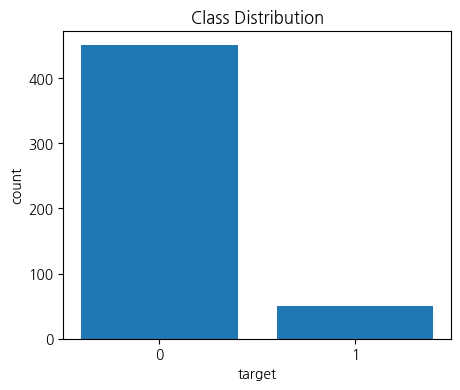

In [7]:
# 시각화

class_counts= df['target'].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.xlabel('target')
plt.ylabel('count')
plt.title('Class Distribution')
plt.show()

- **[3] 불균형 데이터 전처리**

In [ ]:
## ------------------------------------
## 클래스별 데이터 분리
## ------------------------------------

## => target== 0, target== 1
mask= df['target']== 0
majorDF= df[mask]
minorDF= df[~mask]

print(f' [Major Class] {majorDF.shape}, [Minor Class] {minorDF.shape}')

 [Major Class] (450, 7), [Minor Class] (50, 7)


In [17]:
## ------------------------------------
## Upsampling: 소수 클래스-> 증가
            #  복원 방식 샘플링 즉, 동일 데이터가 계속 추출
# 단점: 동일 데이터 존재=> 과대적합 가능성
## ------------------------------------


minorUpDF= resample(minorDF, 
         replace=True, 
         n_samples= majorDF.shape[0], 
         random_state= 10)


print(f'[Minor Class] {minorDF. shape} => [minorUpDF] {minorUpDF. shape} ')


## MajorDF와 합치기
totalDF = pd.concat([majorDF, minorUpDF])

print(f'[totalDF] {totalDF. shape} ')

print(f' [totalDF] {totalDF. shape} ')
print(f'[Target ] {totalDF["target"].value_counts()} ')


[Minor Class] (50, 7) => [minorUpDF] (450, 7) 
[totalDF] (900, 7) 
 [totalDF] (900, 7) 
[Target ] target
0    450
1    450
Name: count, dtype: int64 


In [18]:
## ======================================
## DownSampling : 메인 클래스 => 감소
#  비복원방식 샘플링 즉, 일부 데이터만 추출
#  - 단점 : 데이터 손실
## ======================================


majorDownDF= resample(majorDF, 
         replace=False, ## 비복원
         n_samples= minorDF.shape[0], ## 소수 클래스 개수만큼 
         random_state= 10)


print(f'[majorDF Class] {majorDF.shape} => [majorDownDF] {majorDownDF. shape} ')

## MajorDF와 합치기
totalDF = pd.concat([majorDownDF, minorDF])

print(f'[totalDF] {totalDF. shape}')
print(f'[Target ] {totalDF["target"].value_counts()}')


[majorDF Class] (450, 7) => [majorDownDF] (50, 7) 
[totalDF] (100, 7)
[Target ] target
0    50
1    50
Name: count, dtype: int64


In [20]:
## conda 패키지 설치
# %conda install -c conda-forge imbalanced-learn -y

In [61]:
## -----------------------------------------------------
## SMOTE : 소수 클래스 -> 증가 즉, UpSampling
## 소수 클래스의 데이터와 비슷하게 새로운 데이터 생성
## - 단점 : 과적합 위험이 존재
## -----------------------------------------------------
from imblearn.over_sampling import SMOTE

## 피쳐와 타겟 분리
featureDF = df[df. columns [ :- 1]]
targetSR = df[df.columns [-1]]
print(f'featureDF : {featureDF. shape}, targetSR : {targetSR. shape} ')
print(f'targetSR: {targetSR.value_counts()}')


featureDF : (500, 6), targetSR : (500,) 
targetSR: target
0    450
1     50
Name: count, dtype: int64


In [62]:
## --------------------------------------------
## 학습용 | 테스트용 데이터셋 준비
## --------------------------------------------

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(featureDF,
                                                    targetSR,
                                                    test_size=0.2,
                                                    random_state=10,
                                                    stratify=targetSR)


print(f'학습용 : {X_train.shape}, {y_train.shape}')
print(f'테스트용 : {X_test.shape}, {y_test.shape}')

print('\n학습용 클래스 데이터 구성')
print(y_train.value_counts())

print('\n테스트용 클래스 데이터 구성')
print(y_test.value_counts())

display(featureDF.describe(include='all'))


# 서울 대전 대구 부산 제주 광주


학습용 : (400, 6), (400,)
테스트용 : (100, 6), (100,)

학습용 클래스 데이터 구성
target
0    360
1     40
Name: count, dtype: int64

테스트용 클래스 데이터 구성
target
0    90
1    10
Name: count, dtype: int64


,city,grade,gender,age,visit_count,avg_price
count,500,500,500,500.000000,500.000000,500.000000
unique,6,4,2,NaN,NaN,NaN
top,서울,Bronze,Female,NaN,NaN,NaN
freq,179,238,276,NaN,NaN,NaN
mean,NaN,NaN,NaN,42.016000,4.896000,183239.574000
std,NaN,NaN,NaN,13.235032,2.042922,100343.456969
min,NaN,NaN,NaN,20.000000,1.000000,10515.000000
25%,NaN,NaN,NaN,30.750000,4.000000,97883.250000
50%,NaN,NaN,NaN,41.500000,5.000000,184750.000000
75%,NaN,NaN,NaN,54.000000,6.000000,267398.250000


In [66]:
## ---------------------------------------------------------------------
## 전처리
## - 수치형 컬럼/피쳐 : 값의 범위 일치 => 스케일링 선택 : 데이터 분포, 이상치 여부
##                    정규분포 StandardScaler, 최소/최대 MinMaxScaler , 이상치강한 RobustScaler, MaxAbsScaler
##                     
## - 범주형 컬럼/피쳐 : 수치화 => 인코딩 : 순서 유지 grade
##                                      순서 없음 city, gender
## - 타 겟 컬럼 : 수치화
## ---------------------------------------------------------------------


from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

## => 자료형별 컬럼명
str_cols, strord_cols, num_cols = df.columns[:3:2], df.columns[[1]], df.columns[3 :- 1]

print(f'str_cols : {str_cols}, strord_cols : {strord_cols}, num_cols : {num_cols}')

str_cols : Index(['city', 'gender'], dtype='object'), strord_cols : Index(['grade'], dtype='object'), num_cols : Index(['age', 'visit_count', 'avg_price'], dtype='object')


In [75]:
## -------------------------------------------------------
## => 수치 자료형 전처리 : 분포, 이상치에 따른 스케일러 선택
## -------------------------------------------------------
## 스케일러 인스턴스 생성=> 학습용 데이터만 사용

rbScaler = RobustScaler()
rbScaler.fit(X_train[num_cols])
print(f'rbScaler : {rbScaler.scale_}')



## 훈련용/테스트용 변환
X_train_nums_scaled = rbScaler.transform(X_train[num_cols])
X_Test_nums_scaled = rbScaler.transform(X_test[num_cols])



rbScaler : [2.22500e+01 2.00000e+00 1.72817e+05]


In [71]:
## 범주형 피쳐 자료형 전처리

## 순서 있는 인코더 생성 <= 학습용 데이터셋
ordEncoder = OrdinalEncoder()
ordEncoder.fit(X_train[strord_cols])

## 순서 없는 인코더 생성 <= 학습용 데이터셋
ohEncoder = OneHotEncoder(sparse_output=False)
ohEncoder.fit(X_train[str_cols])


## 학습용, 테스트용 인코딩
X_train_strord = ordEncoder.transform(X_train[strord_cols])
X_test_strord = ordEncoder.transform(X_test[strord_cols])

X_train_str= ohEncoder.transform(X_train[str_cols])
X_test_str= ohEncoder.transform(X_test[str_cols])

In [76]:

# 숫자형 컬럼 스케일링
X_train_nums_scaled = rbScaler.fit_transform(X_train[num_cols])
X_test_nums_scaled = rbScaler.transform(X_test[num_cols])

## => 전처리 완료된 데이터 통합
##
## 학습용, 테스트용 데이터셋
X_train_scaled = np.hstack([X_train_nums_scaled, X_train_strord, X_train_str])
X_test_scaled = np.hstack([X_test_nums_scaled, X_test_strord, X_test_str])

print(f'[TRAIN] {X_train_scaled.shape}, {y_train. shape}\n[CLASS] {y_train. value_counts (normalize=True) } \n')
print(f'[TEST] {X_test_scaled.shape}, {y_test.shape}\n[CLASS] {y_test.value_counts(normalize=True) } \n')

[TRAIN] (400, 12), (400,)
[CLASS] target
0    0.9
1    0.1
Name: proportion, dtype: float64 

[TEST] (100, 12), (100,)
[CLASS] target
0    0.9
1    0.1
Name: proportion, dtype: float64 



In [63]:
# 문자형 컬럼 숫자로 변환
featureDF= pd.get_dummies(
    featureDF,
    columns=["city", "grade", "gender"],
    dtype=int
)

# SMOTE 적용
smote = SMOTE(random_state=42)
featureDF, targetSR = smote.fit_resample(featureDF, targetSR)



In [64]:
# 모델 생성
kModel = KNeighborsClassifier()

# 하이퍼파라미터 후보
param_dict = {
    'n_neighbors': range(1, 31, 2),
    'p': [1, 2],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

# 교차검증 방식
skFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

In [74]:
## 생성형 Upsampling
smote= SMOTE()

## 샘플링
smote = SMOTE()

## 샘플링
X_train_up, y_train_up = smote. fit_resample(X_train_scaled, y_train)

print(f'[TRAIN] {X_train_scaled.shape}, {y_train.shape}\n[CLASS] {y_train. value_counts(normalize=True) } \n')
print(f'[SMOTE] {X_train_up.shape}, {y_train_up.shape}\n[CLASS] {y_train_up.value_counts(normalize=True) } \n')

[TRAIN] (400, 12), (400,)
[CLASS] target
0    0.9
1    0.1
Name: proportion, dtype: float64 

[SMOTE] (720, 12), (720,)
[CLASS] target
0    0.5
1    0.5
Name: proportion, dtype: float64 



In [77]:
## -------------------------------------------------------------------
## class_weight : 모델의 파라미터
## 데이터 수 유지
## - 소수 클래스의 오분류를 더 크게 벌점 처리
## - 모델이 소수 클래스를 더 신경 써서 학습하도록 만드는 방법
## - 단점 : 모델에서 지원해야만 가능한 기능
## - 모델 : LogisticRegression, SVM, DecisionTree, RandomForest
## -------------------------------------------------------------------

## 모델 인스턴스 생성
lrmodel = LogisticRegression(max_iter=1000,
                                class_weight='balanced')


## 클래스별 가중치 적용된 학습 진행
lrmodel.fit(X_train_scaled, y_train)




LogisticRegression(class_weight='balanced', max_iter=1000)

#### ** [정리] ** <hr>
- ** 방법 선택 **
- 간단히 시작 == > 지원하는 모델만 가능 !! class_weight='balanced'
- 데이터가 적다 == > 업샘플링/오버샘플링 기능
- 데이터가 매우 많다 == > 언더샘플링 가능
- **진행 순서**
    1. train/test 분리
    2. train 데이터에만 오버샘플링
    3. test 데이터는 그대로 평가

- **주의점**
- 플링은 train에만 적용